In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
df = pd.read_csv(r"C:\Users\hi\OneDrive\Documents\Working\dataset\samplesuperstore.csv")

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [7]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
df.shape

(10194, 21)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns = df.columns.str.strip()

In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [13]:
df['Year'] = df['Order Date'].dt.year

In [14]:
df['Month'] = df['Order Date'].dt.month_name()

In [16]:
import matplotlib.pyplot as plt

In [17]:
import seaborn as sns

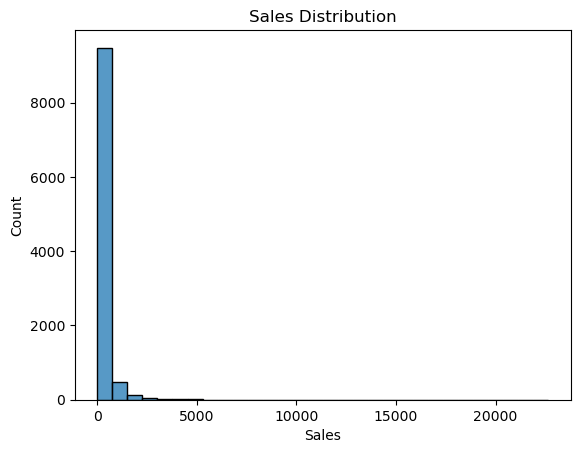

In [18]:
sns.histplot(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.show()

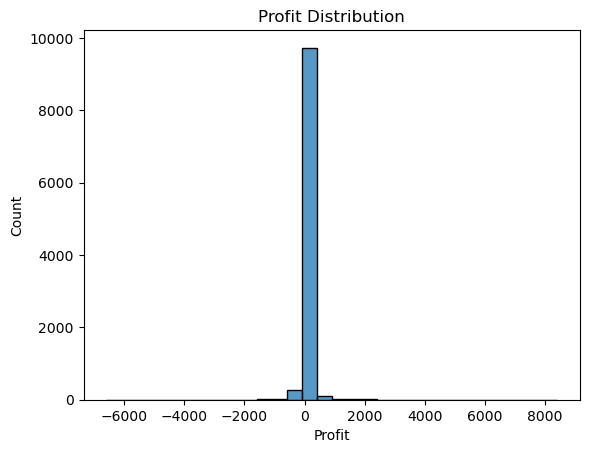

In [19]:
sns.histplot(df['Profit'], bins=30)
plt.title("Profit Distribution")
plt.show()

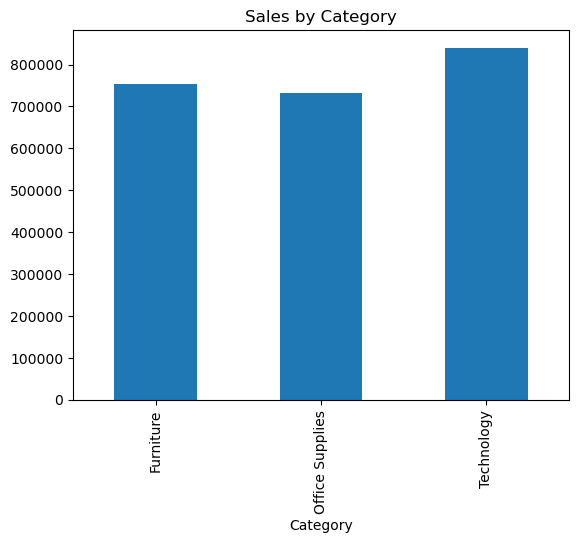

In [20]:
category_sales = df.groupby('Category')['Sales'].sum()
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

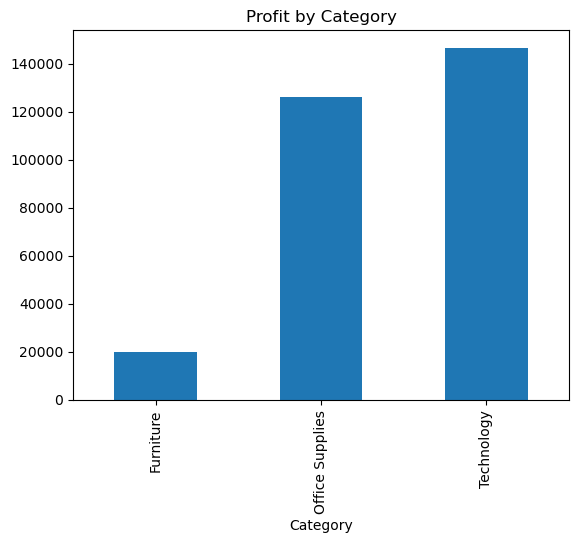

In [21]:
category_profit = df.groupby('Category')['Profit'].sum()
category_profit.plot(kind='bar')
plt.title("Profit by Category")
plt.show()

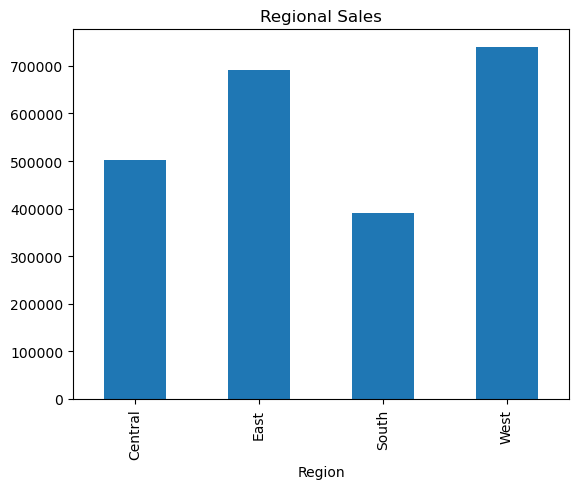

In [22]:
region_sales = df.groupby('Region')['Sales'].sum()
region_sales.plot(kind='bar')
plt.title("Regional Sales")
plt.show()

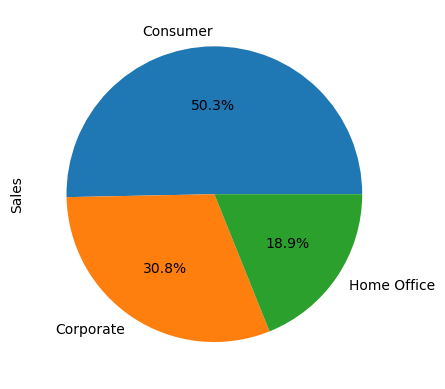

In [23]:
segment_sales = df.groupby('Segment')['Sales'].sum()
segment_sales.plot(kind='pie', autopct='%1.1f%%')
plt.show()

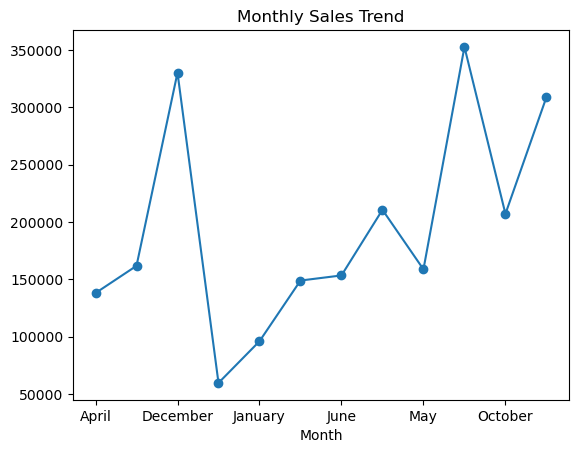

In [24]:
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.show()

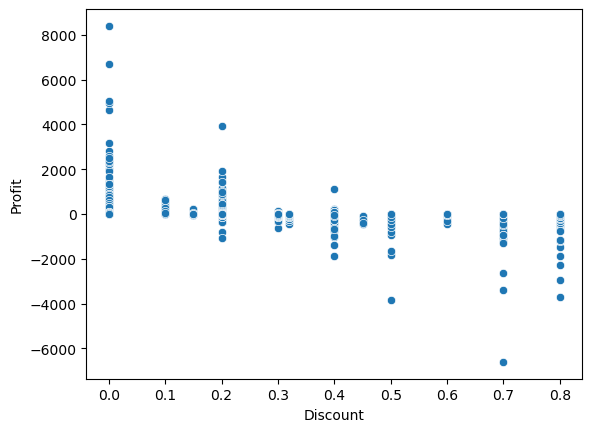

In [25]:
sns.scatterplot(
    x='Discount',
    y='Profit',
    data=df
)
plt.show()

In [26]:
loss_products = df[df['Profit'] < 0]
loss_products[['Product Name','Profit']]\
.sort_values('Profit')\
.head(10)

,Product Name,Profit
6398,Cubify CubeX 3D Printer Double Head Print,-6599.9780
9318,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
821,GBC DocuBind P400 Electric Binding System,-3701.8928
7441,Lexmark MX611dhe Monochrome Laser Printer,-3399.9800
9845,Ibico EPK-21 Electric Binding System,-2929.4845
4037,Cubify CubeX 3D Printer Double Head Print,-2639.9912
9557,Fellowes PB500 Electric Punch Plastic Comb Bin...,-2287.7820
2108,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-1862.3124
4570,GBC DocuBind P400 Electric Binding System,-1850.9464
226,Cisco TelePresence System EX90 Videoconferenci...,-1811.0784


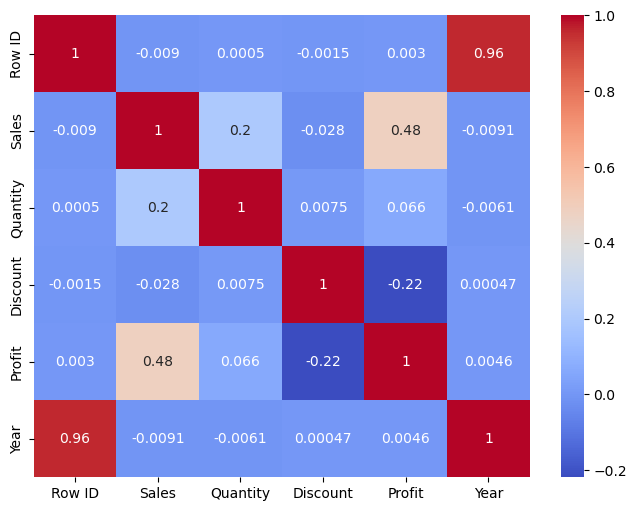

In [27]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [28]:
y = df["Profit"]

In [29]:
X = df.drop("Profit",axis =1)

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train,X_test ,y_train,y_test = train_test_split(X,y, test_size=0.20,random_state=42)

In [37]:
from sklearn.metrics import accuracy_score

In [40]:
print(accuracy_score)

<function accuracy_score at 0x0000022CA0A93100>
